# Cell segmentation tutorial

This tutorial demonstrates how to perform automated cell segmentation on whole slide images (WSI) using LazySlide. We'll walk through the complete workflow from loading a sample lung carcinoma dataset to segmenting individual cells and classifying them into different cell types.

In [1]:
!pip install lazyslide
import lazyslide as zs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 4.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
wsi = zs.datasets.lung_carcinoma(with_data=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


lung_carcinoma.ndpi:   0%|          | 0.00/31.3M [00:00<?, ?B/s]

WSI: /root/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/lung_carcinoma.ndpi
Reader: openslide
Dimensions: 15616×16384 (h×w), 8 Pyramids
Pixel physical size: 0.22731405710129116 MPP
SpatialData object
with coordinate systems:
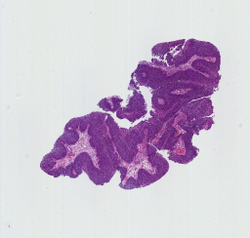

In [3]:
wsi

We'll use **InstanSeg** for cell segmentation, which works optimally with:
- **MPP (Microns Per Pixel): 0.5** - This resolution provides the right balance between detail and computational efficiency
- **Tile size: 512x512 pixels** - Optimal input size for the deep learning model
- **Overlap: 20%** - Ensures seamless segmentation across tile boundaries
- **Background fraction: 95%** - Filters out tiles that are mostly background/empty space

Many WSIs are too large to fit into the CPU/GPU memory to run inference. As usual, we need to tile the WSI in order to work with it.

To improve the cell segmentation quality, it's highly recommended to create overlapping tiles.

In [5]:
zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi,512, overlap=0.2, background_fraction=0.95, mpp=0.5)

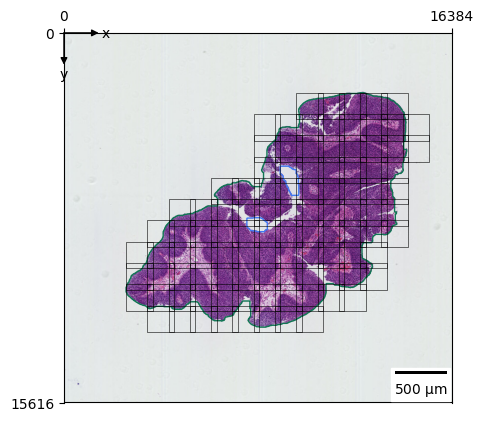

In [6]:
zs.pl.tiles(wsi, linewidth=0.4)

The visualization above shows the tiles that will be processed for cell segmentation. Each rectangle represents a 512x512 pixel tile at 0.5 MPP resolution. Notice how the tiles focus on tissue-rich areas while avoiding empty background regions.

## Cell Segmentation

Now we'll perform the actual cell segmentation using [InstanSeg](https://github.com/instanseg/instanseg). This deep learning model will:
- **Detect individual cells** in each tissue tile
- **Generate precise cell boundaries** as polygon shapes
- **Handle overlapping cells** and complex tissue structures

The `batch_size=32` parameter controls how many tiles are processed simultaneously - adjust this based on your available GPU memory.

In [7]:
zs.seg.cells(wsi, batch_size=32)

instanseg/instanseg_v0_1_0.pt:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

Output()

KeyboardInterrupt: 

### Visualizing Segmented Cells

Let's create an interactive viewer to examine our segmentation results. The viewer will display:
- **Base tissue image** as the background layer
- **Cell boundaries** as polygon overlays (without fill for better visibility)
- **Zoomed region** to inspect segmentation quality in detail



<Axes: >

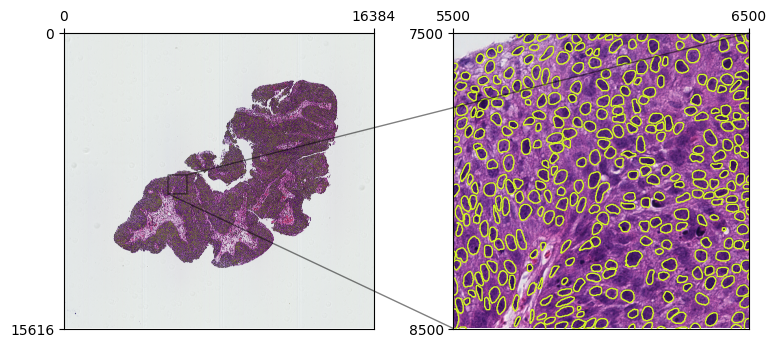

In [ ]:
v = zs.pl.WSIViewer(wsi)
v.add_image()
v.add_polygons("cells", linewidth=1, fill=False)
v.add_zoom(5500, 6500, 7500, 8500)
v.show()

## Cell Segmentation with Cell Type Classification

Apart from only segmenting individual cells, we can also classify them into different cell types in the meanwhile. This step uses a specialized model that analyzes:
- **Cell morphology** (shape, size, internal structure)
- **Tissue context** (surrounding cell types and patterns)
- **Staining characteristics** (intensity and distribution of H&E staining)

Common cell types in lung carcinoma include epithelial cells, stromal cells, immune cells, and various cancer cell subtypes.

The `zs.seg.cell_types` allows for cell classification using [HistoPLUS](https://github.com/owkin/histoplus) (Introduced in LazySlide v0.9.2).

Feature vector can be computed for each cell when using ViT-based model.

In [ ]:
zs.seg.cell_types(wsi, model="histoplus", batch_size=32, extract_features=True)

Output()

In [ ]:
wsi["cell_types_features"]

In [ ]:
v = zs.pl.WSIViewer(wsi)
v.add_image()
v.add_polygons("cell_types", color_by="class")

### Visualizing Cell Types

Now let's create a color-coded visualization where each cell type is displayed in a different color. This makes it easy to:
- **Identify spatial patterns** of different cell types
- **Analyze tissue organization** and cellular neighborhoods  
- **Spot regions of interest** for further analysis

In [ ]:
v.add_zoom(9000, 11000, 10000, 12000, cache=False)
v.show()

## Summary and Next Steps

🎉 **Congratulations!** You've successfully completed cell segmentation and classification on a whole slide image.

### What we accomplished:
- ✅ Loaded and visualized a lung carcinoma WSI dataset
- ✅ Identified tissue regions and created optimal analysis tiles
- ✅ Segmented individual cells using InstanSeg deep learning model
- ✅ Classified cells into different morphological types
- ✅ Created interactive visualizations to explore results

### Possible next steps:
- **Quantitative analysis**: Extract cell counts, sizes, and spatial metrics
- **Biomarker analysis**: Combine with feature extraction for deeper insights  
- **Comparative studies**: Apply to multiple samples for population analysis
- **Custom models**: Train specialized models for your specific tissue types

The segmented cells and their classifications are now stored in your WSI object and ready for downstream analysis!